# PF-5039: Semana 04 — Tarea Programada (Entrega en 7 días)
## Análisis Morfométrico Avanzado: Pipeline de Drepanocitosis y Conteo Celular

**Estudiantes:**
- Franco Castro Chaves, C01886
- Carolina Masis Calvo, A12127
- Emily Chacón Araya, C02047

**Profesor:** Dr. rer. nat. Francisco Siles Canales  
**Universidad de Costa Rica (UCR)** — PRIS-Lab / 2026-II

---
### Instrucciones Generales:
1. Complete los bloques señalados con `# === TODO (Estudiante) ===`.
2. Justifique sus respuestas en las celdas de Markdown correspondientes.
3. Verifique que todas las celdas se ejecuten de forma secuencial sin errores.
4. Exporte este cuaderno completamente ejecutado y genere los artefactos solicitados.

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.patches as mpatches
from skimage import measure, color, segmentation
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'font.sans-serif': 'DejaVu Sans'})
PRIS_NAVY = '#0B1634'
PRIS_RED  = '#B82A3F'
PRIS_GOLD = '#E9C964'

def cargar_imagen(nombre, flags=cv2.IMREAD_GRAYSCALE):
    rutas = [
        Path(f"../../Imagenes_Ejemplo/{nombre}"),
        Path(f"../Imagenes_Ejemplo/{nombre}"),
        Path(rf"c:\Users\siles\Desktop\PF-5039 Análisis de imágenes\2026-II\Imagenes_Ejemplo\{nombre}"),
    ]
    for p in rutas:
        if p.exists():
            return cv2.imdecode(np.fromfile(str(p), dtype=np.uint8), flags)
    return None

print("[OK] Entorno listo.")

[OK] Entorno listo.


---
## Ejercicio 1: Implementación Manual del Algoritmo Two-Pass CCL *(Reto Avanzado)*

**Objetivo:** Comprender en profundidad el algoritmo de componentes conectados mediante su implementación desde cero.

1. Implemente en Python la clase `UnionFind` con operaciones `make_set`, `find` (con compresión de caminos) y `union` (por rango).
2. Implemente la función `two_pass_ccl(binary_img, connectivity=8)`:
   - **Pasada 1 (Raster scan):** Asigne etiquetas provisionales examinando los vecinos causales y registre colisiones con `union()`.
   - **Pasada 2:** Resuelva las equivalencias asignando la etiqueta canónica compactada a cada píxel.
3. Verifique su algoritmo con una imagen sintética pequeña ($8 \times 8$) con al menos 3 componentes y compare el conteo con `cv2.connectedComponents`.

In [35]:
# Resolución Ejercicio 1: Two-Pass CCL + Union-Find

# Paso 1: permite llevar la cuenta de qué números representan en realidad
# la misma célula, aunque en un principio se les haya puesto números distintos.
class UnionFind:
    """Estructura Union-Find con compresión de caminos y unión por rango."""

    def __init__(self):
        self.parent = {}
        self.rank = {}

    def make_set(self, x):
        # Paso 1.1: cuando aparece un número nuevo, se registra en su propio grupo.
        self.parent[x] = x
        self.rank[x] = 0

    def find(self, x):
        # Paso 1.2: para saber a qué grupo pertenece un número, se sigue el rastro.
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y):
        # Paso 1.3: se unen dos grupos en uno solo.
        raiz_x = self.find(x)
        raiz_y = self.find(y)
        if raiz_x == raiz_y:
            return
        if self.rank[raiz_x] < self.rank[raiz_y]:
            self.parent[raiz_x] = raiz_y
        else:
            if self.rank[raiz_x] > self.rank[raiz_y]:
                self.parent[raiz_y] = raiz_x
            else:
                self.parent[raiz_y] = raiz_x
                self.rank[raiz_x] += 1


# Paso 2: aquí se recorre la imagen dos veces para ponerle un número a cada célula que encuentra.
def two_pass_ccl(binary_img, connectivity=8):
    """Etiquetado de componentes conectados en dos pasadas."""

    # Paso 2.1: se preparan las variables que se van a necesitar.
    H, W = binary_img.shape
    etiquetas_prov = np.zeros((H, W), dtype=np.int32)
    uf = UnionFind()
    next_label = 0

    # Paso 2.2: se define qué vecinos se van a revisar de cada píxel.
    if connectivity == 8:
        vecinos_causales = [(-1, -1), (-1, 0), (-1, 1), (0, -1)]
    elif connectivity == 4:
        vecinos_causales = [(-1, 0), (0, -1)]
    else:
        raise ValueError("connectivity debe ser 4 u 8")

    # Paso 2.3: primera pasada. Paso 2.3: primera pasada. se recorre la imagen en dos pasadas para asignar una etiqueta única a cada componente conectado. 
    # Si dos números resultan ser en realidad la misma célula, se anota con union().
    for y in range(H):
        for x in range(W):
            if binary_img[y, x] == 0:
                continue

            etiquetas_vecinas = []
            for dy, dx in vecinos_causales:
                ny, nx = y + dy, x + dx
                if 0 <= ny < H and 0 <= nx < W and etiquetas_prov[ny, nx] > 0:
                    etiquetas_vecinas.append(etiquetas_prov[ny, nx])

            if not etiquetas_vecinas:                    # Ningún vecino tiene número todavía: es una célula nueva.
                next_label += 1
                uf.make_set(next_label)
                etiquetas_prov[y, x] = next_label
            else:                                        # Al menos un vecino tiene número: se toma el menor y se anota la equivalencia.
                etiqueta_min = min(etiquetas_vecinas)
                etiquetas_prov[y, x] = etiqueta_min
                for e in etiquetas_vecinas:
                    uf.union(etiqueta_min, e)

    # Paso 2.4: segunda pasada. Se convierten los números provisionales en números finales.
    raiz_a_canonica = {}
    contador = 0
    etiquetas_final = np.zeros((H, W), dtype=np.int32)
    for y in range(H):
        for x in range(W):
            if etiquetas_prov[y, x] == 0:
                continue
            raiz = uf.find(etiquetas_prov[y, x])
            if raiz not in raiz_a_canonica:
                contador += 1
                raiz_a_canonica[raiz] = contador
            etiquetas_final[y, x] = raiz_a_canonica[raiz]

    # Paso 2.5: se devuelve la imagen ya numerada y el total de células encontradas.
    return etiquetas_final, contador

# Paso 3: se comprueba que la función funciona bien, comparando el resultado con la función ya hecha de OpenCV.
test_img = np.zeros((8, 8), dtype=np.uint8)
test_img[1:3, 1:3] = 1
test_img[4:6, 4:6] = 1
test_img[1:3, 5:7] = 1

etiquetas_mias, n_mio = two_pass_ccl(test_img, connectivity=8)
n_cv, etiquetas_cv = cv2.connectedComponents(test_img, connectivity=8)

print(f"1. Componentes detectados con implementación manual: {n_mio}")
print(f"2. Componentes detectados con cv2.connectedComponents: {n_cv - 1}")
assert n_mio == n_cv - 1, "El conteo no coincide con OpenCV"
print("3. La implementación manual coincide con OpenCV.")

1. Componentes detectados con implementación manual: 3
2. Componentes detectados con cv2.connectedComponents: 3
3. La implementación manual coincide con OpenCV.


---
## Ejercicio 2: Pipeline de Detección de Drepanocitos

**Contexto Clínico:** La drepanocitosis (anemia falciforme) es una hemoglobinopatía genética caracterizada por eritrocitos con forma de hoz o media luna. En un análisis de frotis sanguíneo automatizado, es crucial distinguir entre eritrocitos normales (**discocitos**) y patológicos (**drepanocitos**).

**Instrucciones:**
1. Genere un frotis sintético de $500 \times 700$ píxeles con 20 discocitos circulares ($r \in [18, 26]$) y 8 drepanocitos alargados (elipses con semieje mayor $a \in [28, 42]$ y menor $b \in [7, 12]$) con orientaciones aleatorias.
2. Binarice con el método de **Otsu** y aplique una apertura morfológica con kernel elíptico $3 \times 3$.
3. Etiquete y extraiga propiedades morfométricas con `skimage.measure.regionprops`.
4. Clasifique cada eritrocito usando la **Excentricidad**: **Discocito** ($e < 0.60$) vs **Drepanocito** ($e \geq 0.60$).
5. Visualice los eritrocitos detectados coloreando discocitos en verde y drepanocitos en rojo, y reporte el Índice de Falciformación ($IF = \frac{N_{\text{sickle}}}{N_{\text{total}}} \times 100\%$).

Número de células detectadas: 28
Discocitos (e < 0.60): 20
Drepanocitos (e >= 0.60): 8
Índice de Falciformación (IF): 28.6%


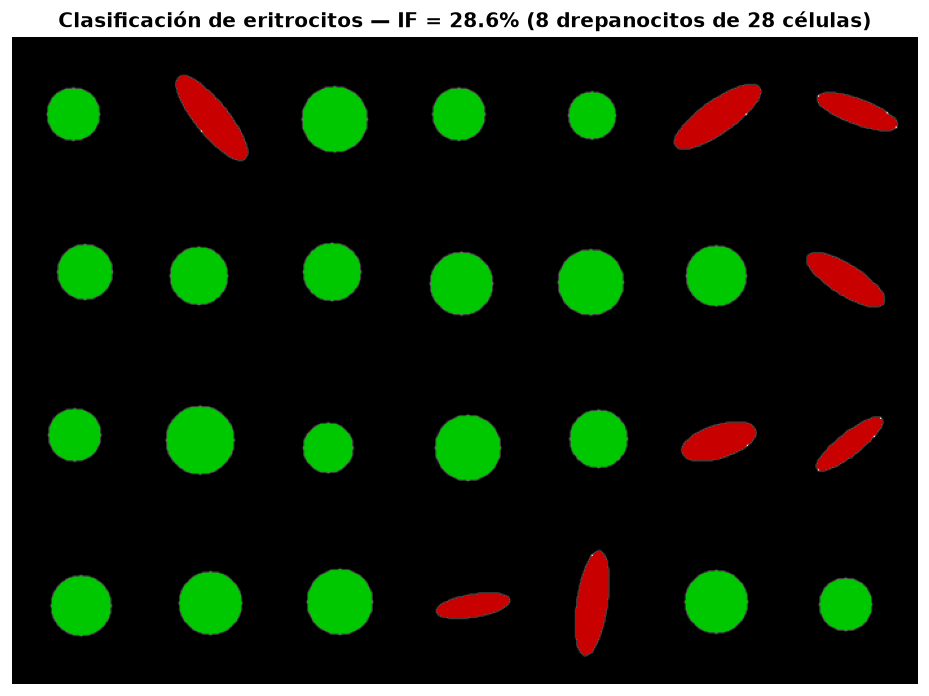

In [34]:
# Resolución ejercicio 2.

# Paso 1: se genera el frotis sintético colocando discocitos y drepanocitos en una cuadrícula para asegurar que ninguno quede pegado a otro.

np.random.seed(2026)
frotis = np.zeros((500, 700), dtype=np.uint8)

# Paso 1.1: se arman 28 casillas (4 filas x 7 columnas) para tener un lugar para cada célula.
filas, columnas = 4, 7
alto_casilla = 500 // filas       # 125 píxeles de alto por casilla
ancho_casilla = 700 // columnas   # 100 píxeles de ancho por casilla

casillas = []
for fila in range(filas):
    for columna in range(columnas):
        centro_y = fila * alto_casilla + alto_casilla // 2
        centro_x = columna * ancho_casilla + ancho_casilla // 2
        casillas.append((centro_x, centro_y))

np.random.shuffle(casillas)  # se desordenan para que no queden en bloques separados

# Paso 1.2: se dibujan los 20 discocitos (círculos) en las primeras 20 casillas de la lista ya desordenada.
for i in range(20):
    centro_x, centro_y = casillas[i]
    centro_x += np.random.randint(-6, 7)  
    centro_y += np.random.randint(-6, 7)  

    radio = np.random.randint(18, 27)     
    cv2.circle(frotis, (centro_x, centro_y), radio, 255, -1)

# Paso 1.3: se dibujan los 8 drepanocitos en las 8 casillas restantes.
for i in range(20, 28):
    centro_x, centro_y = casillas[i]
    centro_x += np.random.randint(-6, 7)
    centro_y += np.random.randint(-6, 7)

    semieje_mayor = np.random.randint(28, 43)  
    semieje_menor = np.random.randint(7, 13)   
    angulo = np.random.randint(0, 180) 

    cv2.ellipse(frotis, (centro_x, centro_y), (semieje_mayor, semieje_menor),
                angulo, 0, 360, 255, -1)


# Paso 2. Binarización de Otsu + apertura morfológica

_, mascara_binaria = cv2.threshold(frotis, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
kernel_eliptico = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
mascara_limpia = cv2.morphologyEx(mascara_binaria, cv2.MORPH_OPEN, kernel_eliptico)

# Paso 3. Etiquetado y extracción de excentricidad

etiquetas = measure.label(mascara_limpia // 255, connectivity=2)
propiedades = measure.regionprops(etiquetas)

print(f"Número de células detectadas: {len(propiedades)}")

# Paso 4. Clasificación y cálculo del Índice de Falciformación (IF)

discocitos = []
drepanocitos = []

for celula in propiedades:
    if celula.eccentricity < 0.60:
        discocitos.append(celula)
    else:
        drepanocitos.append(celula)

total_celulas = len(propiedades)
IF = len(drepanocitos) / total_celulas * 100

print(f"Discocitos (e < 0.60): {len(discocitos)}")
print(f"Drepanocitos (e >= 0.60): {len(drepanocitos)}")
print(f"Índice de Falciformación (IF): {IF:.1f}%")

# Paso 5. Visualización con colores (verde: discocitos, rojo: drepanocitos)


imagen_clasificada = cv2.cvtColor(frotis, cv2.COLOR_GRAY2RGB)

VERDE = (0, 200, 0)
ROJO = (200, 0, 0)

for celula in propiedades:
    color_celula = VERDE if celula.eccentricity < 0.60 else ROJO
    filas_px, columnas_px = celula.coords[:, 0], celula.coords[:, 1]
    imagen_clasificada[filas_px, columnas_px] = color_celula

plt.figure(figsize=(10, 7))
plt.imshow(imagen_clasificada)
plt.title(f"Clasificación de eritrocitos — IF = {IF:.1f}% "
          f"({len(drepanocitos)} drepanocitos de {total_celulas} células)",
          fontweight='bold')
plt.axis('off')
plt.show()

**Conclusión del Ejercicio 2:**
1. ¿Es el umbral $e = 0.60$ adecuado para esta población celular? ¿Qué ocurriría en presencia de eritrocitos sobrepuestos (rouleaux)?*

El umbral $e = 0.60$ resultó adecuado para esta población, ya que produjo la separación esperada entre los 20 discocitos y los 8 drepanocitos. 
Esto se debe a que las geometrías utilizadas para generar ambas poblaciones presentan una separación marcada en su excentricidad. 
Sin embargo, en presencia de eritrocitos sobrepuestos, el algoritmo de etiquetado los uniría en una sola región conectada de forma alargada e irregular. Eso haría que un grupo de discocitos normales pero pegados se clasifique erróneamente como un solo drepanocito, inflando artificialmente el Índice de Falciformación y dando un diagnóstico más grave del que corresponde en realidad.

---
## Ejercicio 3: Calibración Espacial y Especificaciones de Equipos Biomédicos *(Slide 30)*

En la lámina 30 de la lección se presentaron órdenes de magnitud típicos de resolución espacial ($s$ en $\mu\text{m/px}$) para microscopios ópticos ($4\times, 10\times, 40\times, 100\times$), TC axial ($0.3-0.5\,\text{mm/px}$), RM 3T ($0.8-1.0\,\text{mm/px}$) y retinografía ($5-10\,\mu\text{m/px}$).

**Instrucciones:**
1. Seleccione e investigue en la literatura técnica o manuales de fabricantes una modalidad de imagen biomédica distinta (por ejemplo: Tomografía de Coherencia Óptica - OCT, Micro-TC preclínica, o Microscopía de Super-Resolución STED/STORM).
2. Indique en un diccionario de Python: nombre del equipo/modalidad, tamaño de píxel/vóxel nominal ($s$ en $\mu\text{m}$), campo de visión típico (FOV), y calcule el área física real en $\mu\text{m}^2$ de una estructura celular segmentada de $1\,250$ píxeles.
3. Imprima el reporte de calibración formateado con unidades físicas.

In [ ]:
# === TODO (Estudiante) ===

# 1. Definir los parámetros de un equipo biomédico investigado
equipo_info = {
    'modalidad': '',          # ej. 'Tomografía de Coherencia Óptica (SD-OCT Retiniana)'
    'fabricante_modelo': '',  # ej. 'Heidelberg Spectralis OCT'
    'pixel_pitch_lateral_um': 0.0,  # Tamaño de píxel lateral s en micrómetros
    'fov_tipico': '',         # Campo de visión
    'aplicacion_clinica': ''  # Tejido o patología analizada

# Paso 1: se completa el diccionario con datos de un catéter IVUS real
# usado en Costa Rica (Boston Scientific), combinando la ficha del
# fabricante con literatura técnica general de IVUS.

equipo_info = {
    'modalidad': 'Ultrasonido Intravascular (IVUS) coronario',
    'fabricante_modelo': 'Boston Scientific OPTICROSS HD (60 MHz)',
    'pixel_pitch_lateral_um': 200.0,   # resolución lateral típica de IVUS, en micrómetros
    'fov_tipico': 'Penetración máxima 6 mm; catéter de perfil 3.1F (~1 mm de diámetro)',
    'aplicacion_clinica': 'Evaluación de placas ateroscleróticas coronarias y guía de intervención percutánea (PCI)'
}
}
}

# 2. Calcular el área física calibrada para un objeto de 1,250 píxeles
area_pixeles = 1250
# s_um = equipo_info['pixel_pitch_lateral_um']
# area_fisica_um2 = area_pixeles * (s_um ** 2)

# 3. Imprimir ficha técnica y cálculo de área física
pass

=== FICHA DE CALIBRACIÓN ===
Modalidad:            Ultrasonido Intravascular (IVUS) coronario
Fabricante/Modelo:    Boston Scientific OPTICROSS HD (60 MHz)
Tamaño de píxel (s):  200.0 µm/píxel
Campo de visión:      Penetración máxima 6 mm; catéter de perfil 3.1F (aprox. 1 mm de diámetro)
Aplicación clínica:   Evaluación de placas ateroscleróticas coronarias y guía de intervención percutánea (PCI)

Área segmentada:      1250 píxeles
Área física real:     50,000,000.0 µm²  (50.0000 mm²)


---
## Ejercicio 4: Análisis de Morfometría Multi-Escala

**Objetivo:** Comprender el efecto de la resolución espacial y la discretización sobre los descriptores de forma (paradoja de la discretización).

1. Genere una imagen sintética de 5 células circulares idénticas (radio nominal $r = 25$ píxeles).
2. Reduzca progresivamente la escala al 100%, 75%, 50%, 25% y 12% usando `cv2.resize` con interpolación por área (`cv2.INTER_AREA`).
3. Calcule la **Compacticidad Media** ($C = \frac{4\pi A}{P^2}$) en cada nivel de resolución.
4. Grafique la curva de Compacticidad vs. Nivel de Resolución (%) y muestre las imágenes redimensionadas.
5. Determine el límite crítico de resolución y área mínima a partir del cual el cálculo de compacticidad deja de ser confiable ($C < 0.90$).

In [5]:
# === TODO (Estudiante) ===

# 1. Generar imagen base con 5 células circulares
# 2. Redimensionar en niveles: [100, 75, 50, 25, 12]%
# 3. Calcular compacticidad media para cada resolución
resoluciones = [100, 75, 50, 25, 12]
compacticidades_medias = []

# TODO: Implementar ciclo de redimensionamiento y cálculo de C

# 4. Graficar curva de Compacticidad vs Resolución y visualización multi-escala

# 5. Imprimir el umbral de resolución mínimo para C >= 0.90

**Conclusión del Ejercicio 4:**

> *Analice el efecto de la discretización digital sobre el perímetro y la compacticidad. ¿Por qué un círculo digital de pocos píxeles reporta una compacticidad significativamente menor a 1.0? Relaciónelo con la Paradoja de la Escalera vista en clase.*

---
## Ejercicio 5: Reporte Cuantitativo Profesional

**Objetivo:** Integrar todos los componentes del pipeline en un panel clínico profesional de diagnóstico automatizado.

1. Tome el frotis hematológico procesado en el Ejercicio 2 (o una imagen real de microscopía como `mitosis_humana.png`).
2. Diseñe una figura de **6 paneles** ($2 \times 3$) con `plt.subplots`:
   - **Panel 1:** Imagen en escala de grises original.
   - **Panel 2:** Máscara binarizada tras apertura morfológica.
   - **Panel 3:** Mapa de etiquetas coloreado con cuadro de texto superpuesto (resumen cuantitativo con $N$, área media y compacticidad media).
   - **Panel 4:** Elipses equivalentes de inercia superpuestas sobre la imagen original.
   - **Panel 5:** Histograma de distribución de excentricidades con línea vertical indicando el umbral de drepanocitos ($e = 0.60$).
   - **Panel 6:** Diagrama de dispersión (Scatter plot) de **Compacticidad vs. Solidez**, coloreado por área.
3. Guarde la figura como `reporte_semana04.png` con resolución de $150$ DPI.

Tamano de la imagen: (512, 512)


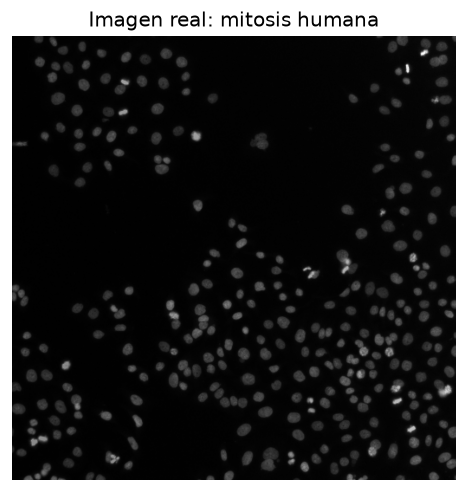

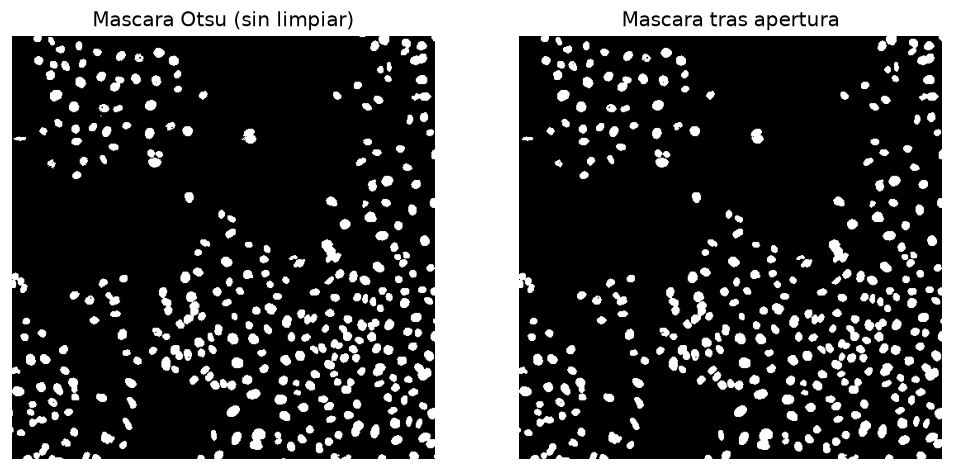

Numero de celulas detectadas: 290
Area media: 101.65172413793104
Compacticidad media: 0.9738507875856769


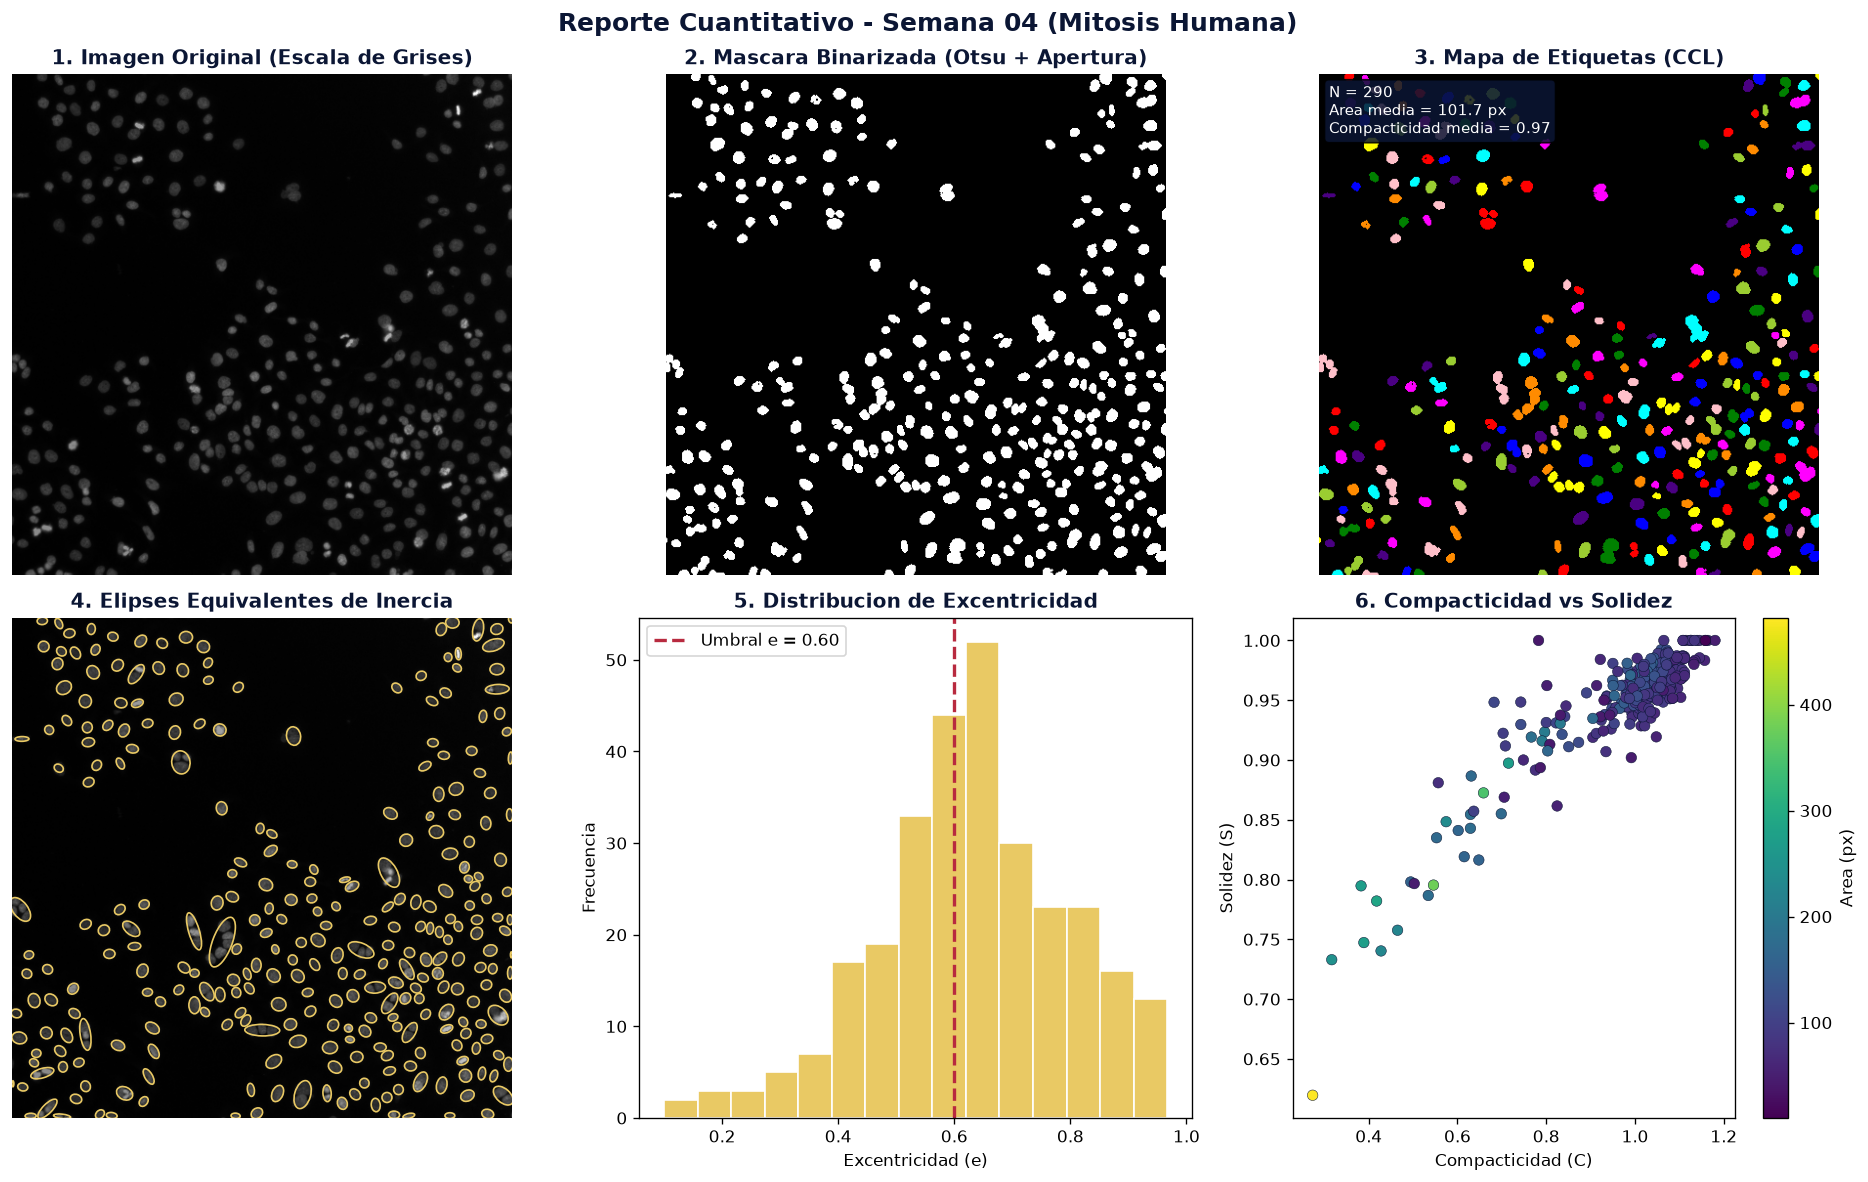

[OK] reporte_semana04.png generado sin errores


In [44]:
# Resolución Ejercicio 5.

# Paso 1: Cargar imagen mitosis_humana.png en escala de grises.

imagen_mitosis = cv2.imread('imagenes/mitosis_humana.png', cv2.IMREAD_GRAYSCALE)
print("Tamano de la imagen:", imagen_mitosis.shape)
plt.imshow(imagen_mitosis, cmap='gray')
plt.title('Imagen real: mitosis humana')
plt.axis('off')
plt.show()

# Paso 2: se binariza la imagen usando el metodo de Otsu, que encuentra automaticamente el umbral que mejor separa las celulas del fondo.

_, mascara_binaria_mitosis = cv2.threshold(imagen_mitosis, 0, 255,
                                             cv2.THRESH_BINARY + cv2.THRESH_OTSU)
kernel_eliptico = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
mascara_limpia_mitosis = cv2.morphologyEx(mascara_binaria_mitosis, cv2.MORPH_OPEN, kernel_eliptico)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(mascara_binaria_mitosis, cmap='gray')
ax[0].set_title('Mascara Otsu (sin limpiar)')
ax[0].axis('off')
ax[1].imshow(mascara_limpia_mitosis, cmap='gray')
ax[1].set_title('Mascara tras apertura')
ax[1].axis('off')
plt.show()

# Paso 3: se etiqueta cada region conectada de la mascara y luego se calculan sus propiedades geometricas.

etiquetas_mitosis = measure.label(mascara_limpia_mitosis // 255, connectivity=2)
propiedades_mitosis = measure.regionprops(etiquetas_mitosis)
total_celulas_mitosis = len(propiedades_mitosis)
print("Numero de celulas detectadas:", total_celulas_mitosis)

# Paso 4: para cada celula detectada se calcula su compacticidad (circularidad),
# y se guardan tambien sus valores de excentricidad, solidez y area

circularidades_mitosis = []
excentricidades_mitosis = []
solideces_mitosis = []
areas_mitosis = []

for celula in propiedades_mitosis:
    # la formula de compacticidad es C = 4 * pi * Area / Perimetro^2
    # un circulo perfecto da C = 1, entre mas irregular sea la forma, mas baja es C
    if celula.perimeter > 0:
        compacticidad = (4 * np.pi * celula.area) / (celula.perimeter ** 2)
    else:
        compacticidad = 0

    circularidades_mitosis.append(compacticidad)
    excentricidades_mitosis.append(celula.eccentricity)
    solideces_mitosis.append(celula.solidity)
    areas_mitosis.append(celula.area)

# se calcula el area promedio y la compacticidad promedio de todas las celulas,
# valores que se van a mostrar como resumen en el reporte final
area_media_mitosis = np.mean(areas_mitosis)
compacticidad_media_mitosis = np.mean(circularidades_mitosis)

print("Area media:", area_media_mitosis)
print("Compacticidad media:", compacticidad_media_mitosis)

# Paso 5: se arma la figura final de 6 paneles que resume todo el analisis
# de la imagen de mitosis humana

fig, ax = plt.subplots(2, 3, figsize=(16, 10))

# Paso 5.1: panel 1, la imagen original en escala de grises
ax[0, 0].imshow(imagen_mitosis, cmap='gray')
ax[0, 0].set_title('1. Imagen Original (Escala de Grises)', fontweight='bold', color=PRIS_NAVY)
ax[0, 0].axis('off')

# Paso 5.2: panel 2, la mascara binarizada despues de la apertura morfologica
ax[0, 1].imshow(mascara_limpia_mitosis, cmap='gray')
ax[0, 1].set_title('2. Mascara Binarizada (Otsu + Apertura)', fontweight='bold', color=PRIS_NAVY)
ax[0, 1].axis('off')

# Paso 5.3: panel 3, el mapa de etiquetas a colores, con un cuadro de texto
# que resume el numero de celulas, el area media y la compacticidad media
mapa_coloreado = color.label2rgb(etiquetas_mitosis, bg_label=0)
ax[0, 2].imshow(mapa_coloreado)
ax[0, 2].set_title('3. Mapa de Etiquetas (CCL)', fontweight='bold', color=PRIS_NAVY)
ax[0, 2].axis('off')

texto_resumen = (f"N = {total_celulas_mitosis}\n"
                  f"Area media = {area_media_mitosis:.1f} px\n"
                  f"Compacticidad media = {compacticidad_media_mitosis:.2f}")
ax[0, 2].text(0.02, 0.98, texto_resumen, transform=ax[0, 2].transAxes,
              fontsize=9, verticalalignment='top', color='white',
              bbox=dict(boxstyle='round', facecolor=PRIS_NAVY, alpha=0.85))

# Paso 5.4: panel 4, las elipses equivalentes de inercia dibujadas
# sobre la imagen original, una por cada celula detectada
ax[1, 0].imshow(imagen_mitosis, cmap='gray')
for celula in propiedades_mitosis:
    cy, cx = celula.centroid
    elipse = Ellipse((cx, cy), width=celula.axis_minor_length, height=celula.axis_major_length,
                      angle=-np.degrees(celula.orientation), edgecolor=PRIS_GOLD,
                      facecolor='none', linewidth=1.0)
    ax[1, 0].add_patch(elipse)
ax[1, 0].set_title('4. Elipses Equivalentes de Inercia', fontweight='bold', color=PRIS_NAVY)
ax[1, 0].axis('off')

# Paso 5.5: panel 5, un histograma con la distribucion de excentricidad
# de todas las celulas, marcando la linea del umbral e = 0.60
ax[1, 1].hist(excentricidades_mitosis, bins=15, color=PRIS_GOLD, edgecolor='white')
ax[1, 1].axvline(0.60, color=PRIS_RED, linestyle='--', linewidth=2, label='Umbral e = 0.60')
ax[1, 1].set_xlabel('Excentricidad (e)')
ax[1, 1].set_ylabel('Frecuencia')
ax[1, 1].set_title('5. Distribucion de Excentricidad', fontweight='bold', color=PRIS_NAVY)
ax[1, 1].legend()

# Paso 5.6: panel 6, un diagrama de dispersion de compacticidad contra
# solidez, coloreando cada punto segun el area de la celula
disp = ax[1, 2].scatter(circularidades_mitosis, solideces_mitosis, c=areas_mitosis,
                         cmap='viridis', s=40, edgecolor=PRIS_NAVY, linewidth=0.3)
ax[1, 2].set_xlabel('Compacticidad (C)')
ax[1, 2].set_ylabel('Solidez (S)')
ax[1, 2].set_title('6. Compacticidad vs Solidez', fontweight='bold', color=PRIS_NAVY)
plt.colorbar(disp, ax=ax[1, 2], label='Area (px)')

# Paso 5.7: titulo general y guardado de la figura final
plt.suptitle('Reporte Cuantitativo - Semana 04 (Mitosis Humana)', fontsize=15,
              fontweight='bold', color=PRIS_NAVY)
plt.tight_layout()
plt.savefig('reporte_semana04.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] reporte_semana04.png generado sin errores")



# 1. Utilizar los datos y máscaras del frotis del Ejercicio 2
# 2. Construir figura de 2x3 paneles con Matplotlib
# 3. Añadir cuadro de texto con estadísticas en Panel 3 (bbox con formato PRIS)
# 4. Trazar elipses de inercia en Panel 4
# 5. Histograma de excentricidad en Panel 5
# 6. Scatter Compacticidad vs Solidez en Panel 6
# 7. Guardar como reporte_semana04.png
# plt.savefig('reporte_semana04.png', dpi=150, bbox_inches='tight')

---
## Rúbrica de Evaluación

| Ejercicio | Puntos | Criterio |
|:----------|:------:|:---------|
| **Ej. 1: Two-Pass CCL + Union-Find** | **25** | Implementación manual correcta, manejo de vecindad causal (4 u 8) y resolución canónica de equivalencias. |
| **Ej. 2: Pipeline Drepanocitosis** | **25** | Generación de frotis, segmentación de Otsu + apertura, extracción de $e$ y clasificación discocitos vs. drepanocitos. |
| **Ej. 3: Calibración Espacial Biomédica** | **15** | Investigación de modalidad clínica real (OCT, $\mu$-CT, STED), especificaciones ($s$, FOV) y cálculo físico riguroso en $\mu\text{m}^2$. |
| **Ej. 4: Morfometría Multi-Escala** | **15** | Análisis cuantitativo del impacto de la resolución sobre la compacticidad ($C$) y determinación del límite de fiabilidad. |
| **Ej. 5: Reporte Cuantitativo Profesional** | **20** | Visualización clínica en 6 paneles con elipses equivalentes, histograma de $e$, scatter $C$ vs $S$, y cuadro de estadísticas. |
| **Total** | **100** | |

**Bonificación (+10 puntos):** Generalizar el Two-Pass CCL con soporte de conectividad parametrizable (4 u 8) o realizar un benchmark de tiempo de cómputo frente a BBDT (`cv2.CCL_BBDT`).